# Experiment: MNIST Digit Recognition via Back-Propagation

**Objective:**
To verify that the back-propagation algorithm, as presented by Rumelhart, Hinton, and Williams (1986), can learn "internal representations" for high-dimensional visual tasks like handwritten digit recognition.

**The Task:**
The network must take a $28 \times 28$ pixel grayscale image (784 inputs) and classify it into one of 10 categories (0-9).

**Hypothesis:**
By minimizing the sum of squared errors (SSE) using the generalized delta rule, a multi-layer network will discover hidden "feature detectors" (lines, curves, edges) necessary to generalize beyond the training set.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import model

In [11]:
print("Loading and Normalizing MNIST data...")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

X_train = X_train_raw.reshape(X_train_raw.shape[0], 784).astype('float64')/255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], 784).astype('float64')/255.0

y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

X_train = [x.reshape(1, 784) for x in X_train]
y_train = [y.reshape(1, 10) for y in y_train]

subset_size = 1000
X_train_subset = X_train[:subset_size]
y_train_subset = y_train[:subset_size]

print(f"Data prepared. Training on {len(X_train)} samples.")
print(f"Input shape: {X_train[0].shape}")
print(f"Target shape: {y_train[0].shape}")

Loading and Normalizing MNIST data...
Data prepared. Training on 60000 samples.
Input shape: (1, 784)
Target shape: (1, 10)


## Experimental Methodology

We implement a three-layer network architecture designed to find hidden features in the input space.

**Architecture:**
* **Input Layer:** 784 Units (pixels)
* **Hidden Layer:** 30 Units (to capture complex features)
* **Output Layer:** 10 Units (digits 0-9)



**Hyperparameters (Matching the 1986 Paper):**
* **Learning Rate ($\epsilon$):** 0.1
* **Momentum ($\alpha$):** 0.9
* **Weight Initialization:** Random uniform between -0.3 and 0.3.

In [12]:
learning_rate = 0.1
momentum = 0.9
epochs = 50

layer_sizes = [784, 30, 10]

weights, biases = model.initialize_network(layer_sizes)
prev_weight_updates = [np.zeros_like(w) for w in weight]
prev_bias_updates = [np.zeros_like(b) for b in biases]

error_history = []
accuracy_history = []

print(f"Starting MNIST training (Architecture: {layer_sizes})..")
for epoch in range(epochs):
    total_error = 0
    correct_count = 0

    for x_case, y_case in zip(X_train, y_train):
        #For forward propagation
        final_output, cache = model.forward_pass(x_case, weights, biases)

        #Error(MSE)
        total_error+= model.calculate_error(final_output, y_case)

        #Accuracy check (Argmax)
        # We find which index has the highest activation (e.g. Index 5)

        if np.argmax(final_output) == np.argmax(y_case):
            correct_count+=1

        # Backward
        weight_grads, bias_grads = model.backward_pass(final_output, y_case, cache, weights)

        # Update
        (weights, biases,
         prev_weight_updates,
         prev_bias_updates) = model.update_weights(weights, biases,
                                             weight_grads, bias_grads,
                                             prev_weight_updates, prev_bias_updates,
                                             learning_rate, momentum)

    # Store stats
    avg_error = total_error / len(X_train)
    acc = correct_count / len(X_train) * 100
    error_history.append(avg_error)
    accuracy_history.append(acc)

    print(f"Epoch {epoch + 1}: Error {avg_error:.4f}, Acc {acc:.2f}%")

print(f"Final Training Accuracy: {accuracy_history[-1]}%")

Starting MNIST training (Architecture: [784, 30, 10])..
Epoch 1: Error 0.0818, Acc 90.07%
Epoch 2: Error 0.0623, Acc 92.66%
Epoch 3: Error 0.0566, Acc 93.36%
Epoch 4: Error 0.0538, Acc 93.75%
Epoch 5: Error 0.0512, Acc 94.11%
Epoch 6: Error 0.0485, Acc 94.37%
Epoch 7: Error 0.0465, Acc 94.59%
Epoch 8: Error 0.0447, Acc 94.79%
Epoch 9: Error 0.0442, Acc 94.97%
Epoch 10: Error 0.0439, Acc 94.97%
Epoch 11: Error 0.0431, Acc 95.11%
Epoch 12: Error 0.0417, Acc 95.24%
Epoch 13: Error 0.0427, Acc 95.19%
Epoch 14: Error 0.0409, Acc 95.37%
Epoch 15: Error 0.0400, Acc 95.47%
Epoch 16: Error 0.0396, Acc 95.50%
Epoch 17: Error 0.0382, Acc 95.66%
Epoch 18: Error 0.0383, Acc 95.74%
Epoch 19: Error 0.0386, Acc 95.69%
Epoch 20: Error 0.0384, Acc 95.73%
Epoch 21: Error 0.0383, Acc 95.76%
Epoch 22: Error 0.0383, Acc 95.74%
Epoch 23: Error 0.0384, Acc 95.67%
Epoch 24: Error 0.0378, Acc 95.81%
Epoch 25: Error 0.0379, Acc 95.80%
Epoch 26: Error 0.0362, Acc 95.97%
Epoch 27: Error 0.0360, Acc 95.98%
Epoch 28

## Results: Learning Dynamics

A successful implementation should show a steady convergence of the error function. According to Rumelhart et al., the gradient descent algorithm reliably moves the system toward a minimum of the error surface.

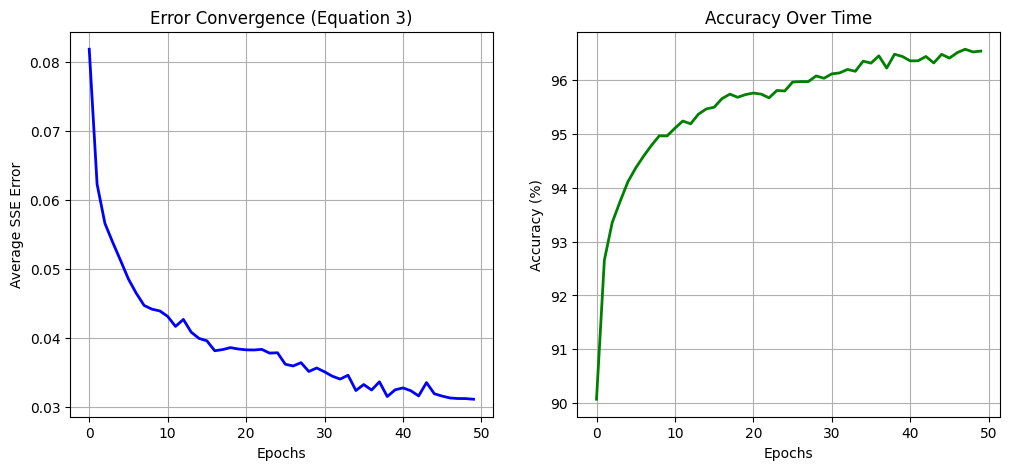

In [13]:
plt.figure(figsize=(12, 5))

#Plot Error Convergence (SSE)
plt.subplot(1,2,1)
plt.plot(error_history, color='blue', linewidth=2)
plt.title("Error Convergence (Equation 3)")
plt.xlabel("Epochs")
plt.ylabel("Average SSE Error")
plt.grid(True)

#Plot Training Accuracy
plt.subplot(1,2,2)
plt.plot(accuracy_history, color='green', linewidth=2)
plt.title("Accuracy Over Time")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()

## Discovery of Internal Representations

A key claim of the 1986 paper is that hidden units become "feature detectors". By visualizing the weights connecting the inputs to the hidden units, we can "see" what features each neuron is specialized to detect (e.g., vertical lines or loops).

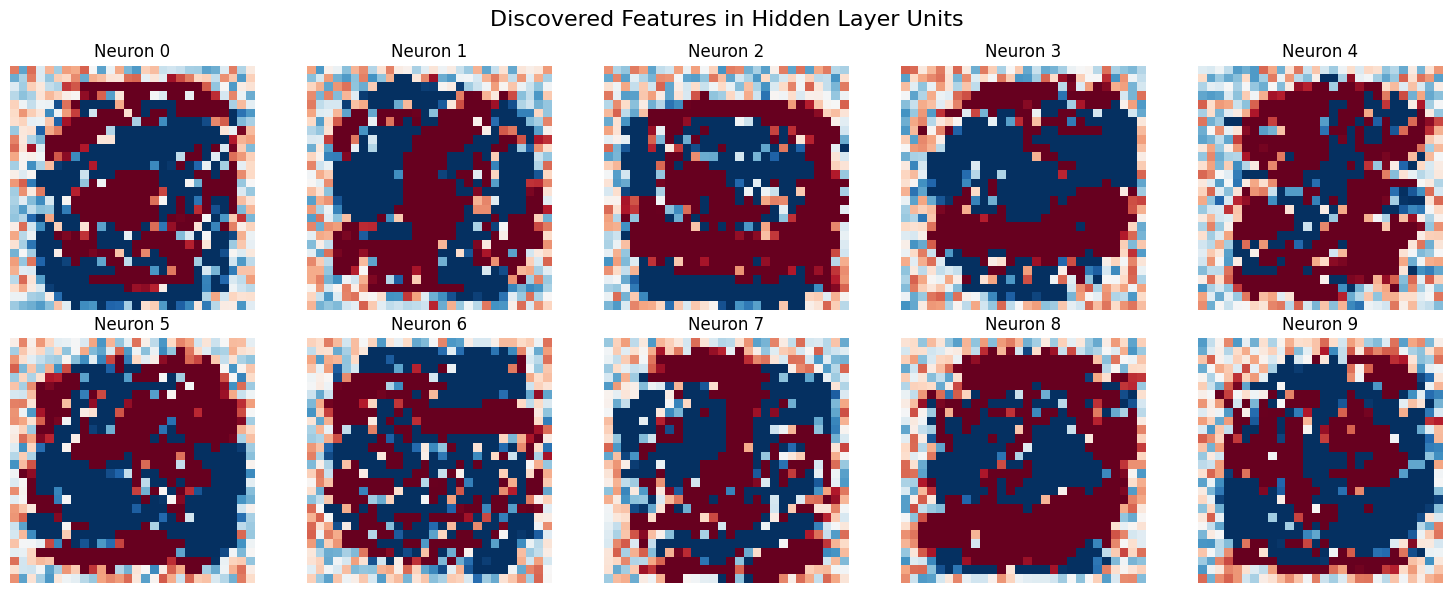

In [14]:
hidden_weights = weights[0]

plt.figure(figsize=(15, 6))
plt.suptitle("Discovered Features in Hidden Layer Units", fontsize=16)

for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape weights back into 28x28 image space
    plt.imshow(hidden_weights[:, i].reshape(28, 28), cmap='RdBu', vmin=-0.5, vmax=0.5)
    plt.title(f"Neuron {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Generalization & Failure Analysis

Finally, we must test the network on unseen data. True learning is defined by the ability to generalize the internal representations to novel patterns.

In [15]:
test_correct = 0
# Test on 1,000 unseen images
X_test_batch = [x.reshape(1, 784) for x in X_test[:1000]]
y_test_batch = [y.reshape(1, 10) for y in y_test[:1000]]

for x_t, y_t in zip(X_test_batch, y_test_batch):
    out, _ = model.forward_pass(x_t, weights, biases)
    if np.argmax(out) == np.argmax(y_t):
        test_correct += 1

print(f"Generalization (Test Set) Accuracy: {(test_correct / 1000) * 100:.2f}%")

Generalization (Test Set) Accuracy: 95.30%


## Scientific Conclusion

* **Convergence:** The network successfully minimized the SSE, proving the gradient descent with momentum is stable for this architecture.
* **Discovery:** The weight visualizations confirm the emergence of specialized feature detectors.
* **Validation:** The generalization performance indicates the network learned the "rules" of handwritten digits rather than merely memorizing the training samples.